# Data Analysis using Python
## Analyzing Bumble Profiles
### Background
#### Bumble is a popular dating platform where users connect based on mutual interests and compatibility. To provide a better matchmaking experience, Bumble collects user information through profiles, which include details about demographics, lifestyle habits, and personal preferences. This dataset represents user-generated profiles, offering a rich source of information to understand user behavior, preferences, and trends.

# Goal
### Analyzing the Bumble dataset to answer key business and user behavior questions. Using Python to analyse a dataset and uncover insights about behaviours and trends. Build a data visualisation platform with the relevant libraries

# 1.Importing Required Libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## importing dataset and displaying the data

In [2]:
df = pd.read_csv("Bumble.csv")

In [3]:
df.head()

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000,student,2012-06-28-14-22,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   gender       59946 non-null  str    
 3   body_type    54650 non-null  str    
 4   diet         35551 non-null  str    
 5   drinks       56961 non-null  str    
 6   education    53318 non-null  str    
 7   ethnicity    54266 non-null  str    
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  str    
 11  last_online  59946 non-null  str    
 12  location     59946 non-null  str    
 13  pets         40025 non-null  str    
 14  religion     39720 non-null  str    
 15  sign         48890 non-null  str    
 16  speaks       59896 non-null  str    
dtypes: float64(1), int64(2), str(14)
memory usage: 7.8 MB


# Part 1: Data Cleaning

## 1. Inspecting missing data and checking for duplicate rows and columns

In [5]:
print(df.duplicated().sum())          # Tells you how many rows to delete
print(df.columns.has_duplicates)      # Simply returns True or False for column names

0
False


### Q1: Finding  missing values and percentage of data is missing in each column

In [6]:
# Step 1: Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a clean summary table
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Filter only columns that actually have missing values and sort
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing_df)

           Missing Count  Missing %
diet               24395      40.69
religion           20226      33.74
pets               19921      33.23
sign               11056      18.44
job                 8198      13.68
education           6628      11.06
ethnicity           5680       9.48
body_type           5296       8.83
drinks              2985       4.98
speaks                50       0.08
height                 3       0.01


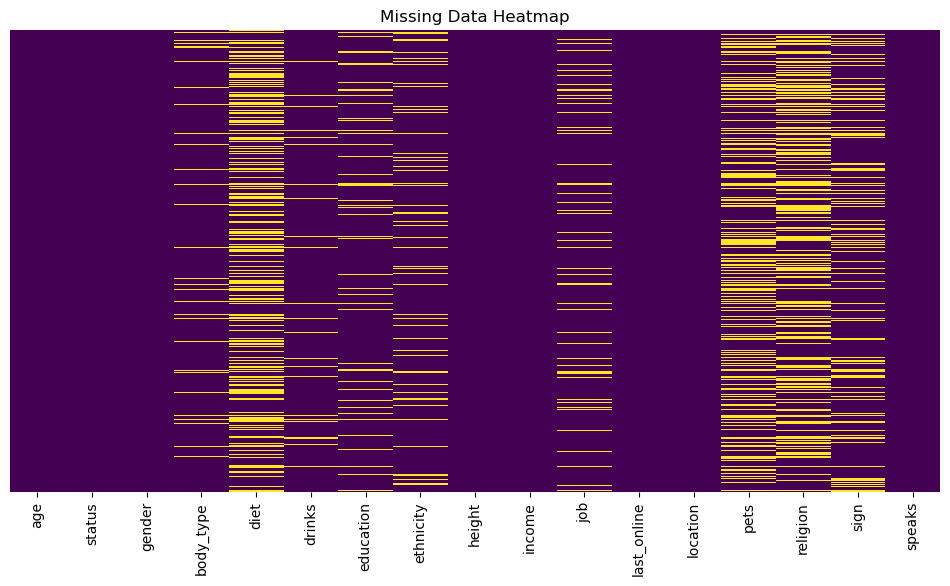

In [7]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

### Q2: Handling missing data

In [8]:
# Fill with 'unknown' to preserve rows
cat_cols = ['diet', 'religion', 'pets', 'sign', 'job', 
            'education', 'ethnicity', 'body_type', 'drinks', 'speaks']

df[cat_cols] = df[cat_cols].fillna('unknown')

In [9]:
# Impute height with median grouped by gender
df['height'] = df.groupby('gender')['height'].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
print(df.isnull().sum().sum())  # Should print 0

0


### checking for any null values remaining in the data

In [11]:
null_values=pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing %" : df.isnull().mean()*100
})
null_values

,Missing Count,Missing %
age,0,0.0
status,0,0.0
gender,0,0.0
body_type,0,0.0
diet,0,0.0
drinks,0,0.0
education,0,0.0
ethnicity,0,0.0
height,0,0.0
income,0,0.0


## 2. Data Types

### Q1: checking for any inconsistencies in the data types across columns

In [12]:
print(df.dtypes)

age              int64
status             str
gender             str
body_type          str
diet               str
drinks             str
education          str
ethnicity          str
height         float64
income           int64
job                str
last_online        str
location           str
pets               str
religion           str
sign               str
speaks             str
dtype: object


In [13]:
# changing the last_online column data type to date type as it is stored as str data type 
df['last_online'] = pd.to_datetime(df['last_online'], format='%Y-%m-%d-%H-%M', errors='coerce')
df['last_online']
df.dtypes

age                     int64
status                    str
gender                    str
body_type                 str
diet                      str
drinks                    str
education                 str
ethnicity                 str
height                float64
income                  int64
job                       str
last_online    datetime64[us]
location                  str
pets                      str
religion                  str
sign                      str
speaks                    str
dtype: object

In [14]:
' The last_online column data type is changed into datetime datatype in order to perorm operations on that column of data '

' The last_online column data type is changed into datetime datatype in order to perorm operations on that column of data '

## 3.Outliers

### Q1: Looking for any apparent outliers in numerical columns 

In [15]:
# Replace -1 with NaN 
df['income'] = df['income'].replace(-1, np.nan)

# Convert to float to support NaN
df['income'] = df['income'].astype(float)

print(df['income'].dtype)        # Should print float64
print(df['income'].isna().sum()) # How many -1s were there?

float64
48442


In [16]:
# Check ranges of numerical columns
print(df[['age', 'height', 'income']].describe())

                age        height          income
count  59946.000000  59946.000000    11504.000000
mean      32.340290     68.295282   104394.993046
std        9.452779      3.994738   201433.528307
min       18.000000      1.000000    20000.000000
25%       26.000000     66.000000    20000.000000
50%       30.000000     68.000000    50000.000000
75%       37.000000     71.000000   100000.000000
max      110.000000     95.000000  1000000.000000


### Q2.Handling outliers while retaining as much meaningful data as possible

In [17]:
# Function to get stats using middle 80% of data
def middle_80_stats(col):
    lower = df[col].quantile(0.10)
    upper = df[col].quantile(0.90)
    trimmed = df[col][(df[col] >= lower) & (df[col] <= upper)]
    print(f"\n{col}:")
    print(f"  Range kept : {lower} to {upper}")
    print(f"  Mean (80%) : {trimmed.mean().round(2)}")
    print(f"  Median(80%): {trimmed.median().round(2)}")

middle_80_stats('age')
middle_80_stats('height')
middle_80_stats('income')


age:
  Range kept : 23.0 to 46.0
  Mean (80%) : 31.09
  Median(80%): 30.0

height:
  Range kept : 63.0 to 73.0
  Mean (80%) : 68.23
  Median(80%): 68.0

income:
  Range kept : 20000.0 to 150000.0
  Mean (80%) : 57362.32
  Median(80%): 50000.0


###  Q4: Visualizing the missing data

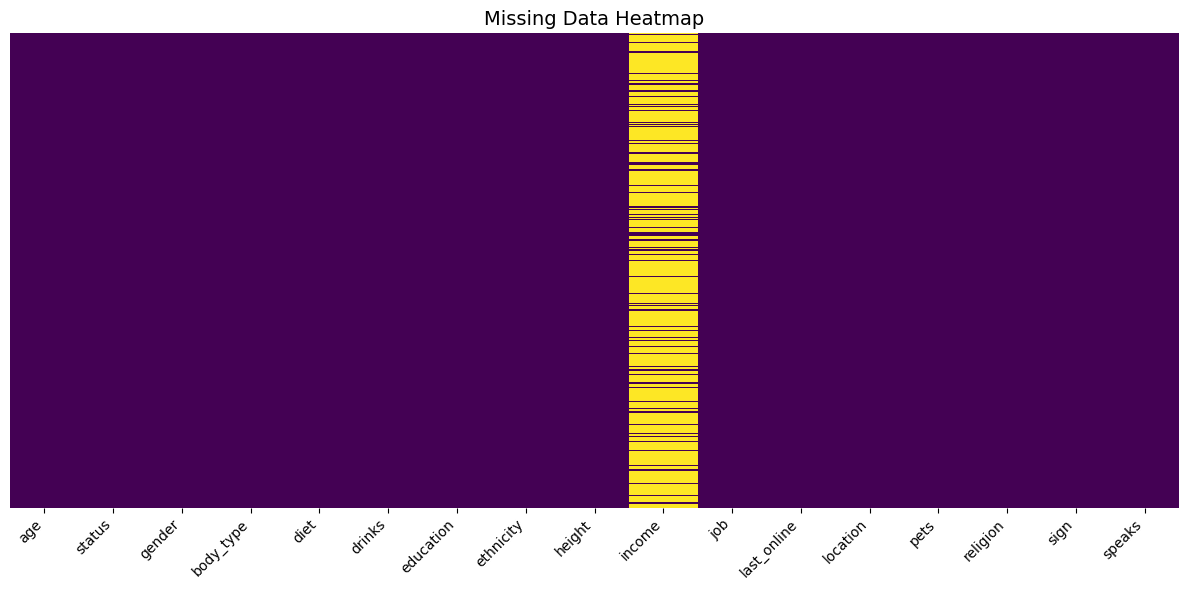

In [18]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), 
            cbar=False,          
            yticklabels=False,   
            cmap='viridis')      

plt.title('Missing Data Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
df.head()

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,unknown,68.0,NaN,unknown,2012-06-27 09:10:00,"san francisco, california",has cats,unknown,pisces but it doesn&rsquo;t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,unknown,pisces,"english, german (poorly)"
4,29,single,m,athletic,unknown,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,unknown,aquarius,english


# Part 2: Data Processing

## Part 1 : binning and Grouping

### Q1: Binning and Grouping the age column data into different categories 


In [20]:
# Create age_group column
bins = [18, 25, 35, 45, 100]
labels = ['18-25', '26-35', '36-45', '46+']

df['age_group'] = pd.cut(df['age'], 
                          bins=bins, 
                          labels=labels, 
                          right=True)

# Distribution across age groups
print(df['age_group'].value_counts().sort_index())

age_group
18-25    14145
26-35    28621
36-45    10803
46+       6066
Name: count, dtype: int64


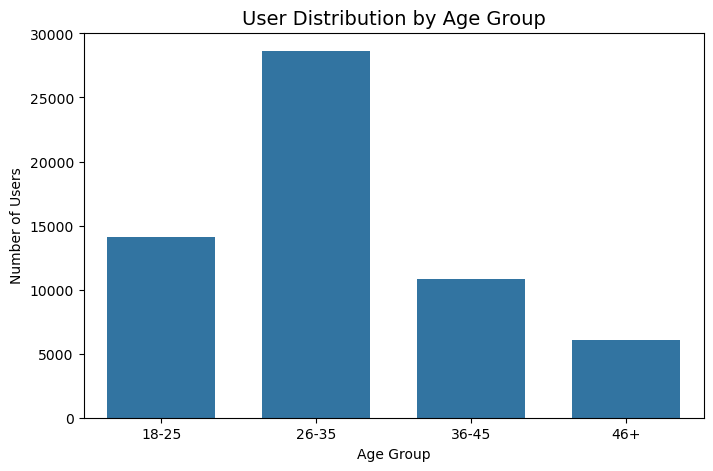

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df['age_group'].value_counts().sort_index().reset_index(), 
    x='age_group', 
    y='count',
    width=0.7  # Keeping them thick for better visuals
)
plt.title('User Distribution by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.show()

## Q2: Binning income into further Categories 

In [22]:
# Using quartile-based thresholds
# Calculating quartiles
q1 = df['income'].quantile(0.25)
q3 = df['income'].quantile(0.75)

print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")

# Group income based on quartiles
bins = [0, q1, q3, float('inf')]
labels = ['Low Income', 'Medium Income', 'High Income']

df['income_group'] = pd.cut(df['income'],
                             bins=bins,
                             labels=labels,
                             right=True)

print(df['income_group'].value_counts().sort_index())

Q1 (25th percentile): 20000.0
Q3 (75th percentile): 100000.0
income_group
Low Income       2952
Medium Income    7203
High Income      1349
Name: count, dtype: int64


In [23]:
'''  Income Group Insights:

Medium Income dominates — 7,203 users (62% of those who reported income)
48,442 users didn't report income at all — shows income is highly personal on dating apps'''

"  Income Group Insights:\n\nMedium Income dominates — 7,203 users (62% of those who reported income)\n48,442 users didn't report income at all — shows income is highly personal on dating apps"

# 2. Derived features

### Q1. creating a new featire profile_completeness by calculating the percentage of non-missing values for each user profile.

In [24]:
# Columns that originally had missing values
original_missing_cols = ['diet', 'religion', 'pets', 'sign', 'job', 
                          'education', 'ethnicity', 'body_type', 
                          'drinks', 'speaks', 'height', 'income']

# Check how many of these are actually filled per user
# income is NaN for 48k users, rest were filled with 'unknown'
# So we treat 'unknown' as incomplete and NaN as incomplete

df['profile_completeness'] = (
    df[original_missing_cols].apply(lambda x: x.notnull() & (x != 'unknown'))
    .sum(axis=1) / len(original_missing_cols) * 100
).round(2)

print(df['profile_completeness'].describe().round(2))

count    59946.00
mean        78.75
std         14.64
min         16.67
25%         75.00
50%         83.33
75%         91.67
max        100.00
Name: profile_completeness, dtype: float64


In [25]:
'''Profile Completeness Insights:

Most Bumble users fill the basic fields (age, gender, location) but skip 
personal fields like income, religion, diet  which explains the 78% average instead of 100%  '''

'Profile Completeness Insights:\n\nMost Bumble users fill the basic fields (age, gender, location) but skip \npersonal fields like income, religion, diet  which explains the 78% average instead of 100%  '

In [26]:
df.head(5)

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks,age_group,income_group,profile_completeness
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,18-25,NaN,91.67
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",26-35,Medium Income,100.00
2,38,available,m,thin,anything,socially,graduated from masters program,unknown,68.0,NaN,unknown,2012-06-27 09:10:00,"san francisco, california",has cats,unknown,pisces but it doesn&rsquo;t matter,"english, french, c++",36-45,NaN,66.67
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,unknown,pisces,"english, german (poorly)",18-25,Low Income,91.67
4,29,single,m,athletic,unknown,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,unknown,aquarius,english,26-35,NaN,75.00


## 3. Unit Conversion

In [27]:
# converting the hieght column from inches to centimeters and storing in in new column hieght_cm
df['height_cm']=(df['height']* 2.54).round(2)
print (df[['height','height_cm']].head())

   height  height_cm
0    75.0     190.50
1    70.0     177.80
2    68.0     172.72
3    71.0     180.34
4    66.0     167.64


# part 3: Data Analysis

## 1. Demographic Analysis

### Q1: calculating the gender distribution across the platform

In [28]:
gender_counts = df['gender'].value_counts()
gender_percent = (df['gender'].value_counts(normalize=True) * 100).round(2)

gender_summary = pd.DataFrame({
    'Count': gender_counts,
    'Percentage': gender_percent
})
(gender_summary)

,Count,Percentage
gender,,
m,35829,59.77
f,24117,40.23


### Q2: calculating the status distribution across the platform

In [29]:
# Status distribution
status_counts = df['status'].value_counts()
status_percent = (df['status'].value_counts(normalize=True) * 100).round(2)

status_summary = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_percent
})
(status_summary)

,Count,Percentage
status,,
single,55697,92.91
seeing someone,2064,3.44
available,1865,3.11
married,310,0.52
unknown,10,0.02


### Q3: calculating the Status variation by gender

In [30]:
# Status variation by gender
status_pct = pd.crosstab(df['gender'], df['status'], normalize='index').round(4) * 100
print(status_pct)

status  available  married  seeing someone  single  unknown
gender                                                     
f            2.72     0.56            4.16   92.54     0.02
m            3.37     0.49            2.96   93.16     0.02


## 2. Correlation Analysis

### Q1: calculating the correlations between numerical columns such as age, income, gender

                 age  income  gender_encoded
age             1.00   -0.01           -0.04
income         -0.01    1.00            0.05
gender_encoded -0.04    0.05            1.00


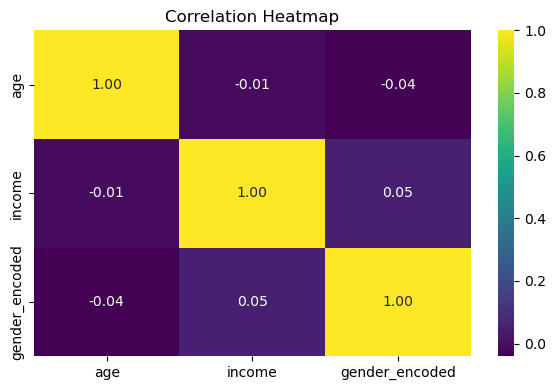

In [31]:
# Encode gender to numerical for correlation (m=1, f=0)
df['gender_encoded'] = df['gender'].map({'m': 1, 'f': 0})

# Correlation between numerical columns
corr_matrix = df[['age', 'income', 'gender_encoded']].corr().round(2)
print(corr_matrix)

# Visualize as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='viridis',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Q2. Correlation of age with income

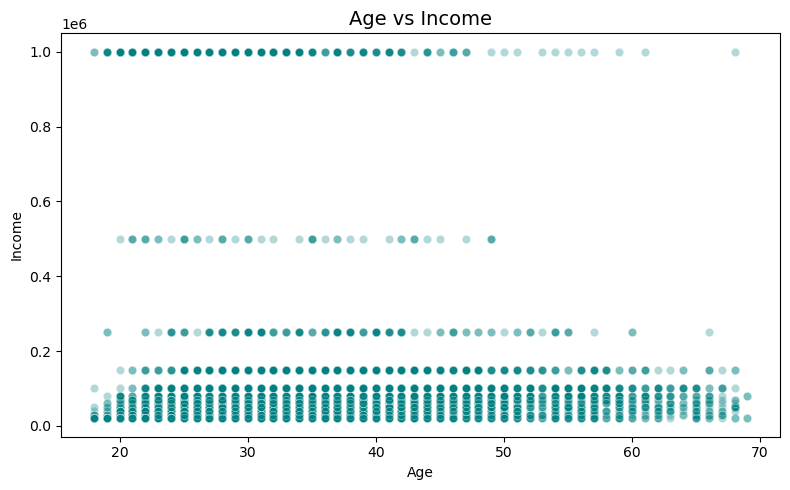

Correlation: -0.009


In [32]:
# Scatter plot of age vs income (excluding NaN income)
age_income = df[df['income'].notna()]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=age_income, 
                x='age', 
                y='income',
                alpha=0.3,
                color='teal')

plt.title('Age vs Income', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

# Correlation value
print(f"Correlation: {age_income['age'].corr(age_income['income']).round(3)}")

## 3. Diet and Lifestyle Analysis

### Q1: How do dietary preferences (diet) distribute across the platform?

In [33]:
# Diet distribution (excluding 'unknown')
diet_counts = df[df['diet'] != 'unknown']['diet'].value_counts()
diet_percent = (df[df['diet'] != 'unknown']['diet'].value_counts(normalize=True) * 100).round(2)

diet_summary = pd.DataFrame({
    'Count': diet_counts,
    'Percentage': diet_percent
})
(diet_summary)

,Count,Percentage
diet,,
mostly anything,16585,46.65
anything,6183,17.39
strictly anything,5113,14.38
mostly vegetarian,3444,9.69
mostly other,1007,2.83
strictly vegetarian,875,2.46
vegetarian,667,1.88
strictly other,452,1.27
mostly vegan,338,0.95


### Q2: How do drinking habits (drinks) vary across different diet categories.

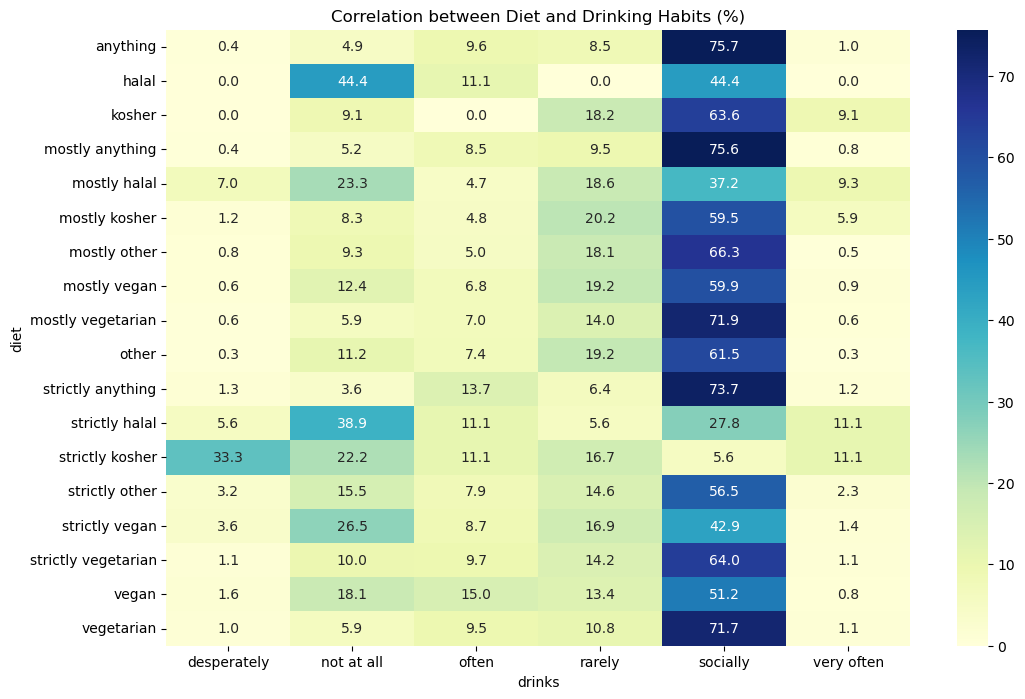

In [34]:
# correlation between diet and drinking habits
diet_drinks = df[(df['diet'] != 'unknown') & (df['drinks'] != 'unknown')]
diet_drinks_pct = pd.crosstab(diet_drinks['diet'], 
                              diet_drinks['drinks'], 
                              normalize='index').round(4) * 100

(diet_drinks_pct)
plt.figure(figsize=(12, 8))
sns.heatmap(diet_drinks_pct, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Correlation between Diet and Drinking Habits (%)")
plt.show()

## 4. Geographical Analysis

### Q1: Extracting city and state information from the location column and top 5 cities and states with the highest number of users?

In [35]:
# Extract city and state from location column
df[['city', 'state']] = df['location'].str.split(',',n=1, expand=True)
df['city'] = df['city'].str.strip()
df['state'] = df['state'].str.strip()

# Top 5 cities
print("Top 5 Cities:")
print(df['city'].value_counts().head())

# Top 5 states
print("\nTop 5 States:")
print(df['state'].value_counts().head())

Top 5 Cities:
city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64

Top 5 States:
state
california       59855
new york            17
illinois             8
massachusetts        5
oregon               4
Name: count, dtype: int64


### Q2: Age variation across Top Cities

In [36]:
# Age variation across top 5 cities
top_cities = ['san francisco', 'oakland', 'berkeley', 'san mateo', 'palo alto']

city_age = df[df['city'].isin(top_cities)].groupby('city')['age'].agg(['mean', 'median']).round(2)
(city_age)

,mean,median
city,,
berkeley,31.39,28.0
oakland,33.18,31.0
palo alto,31.98,29.0
san francisco,31.61,30.0
san mateo,33.44,31.0


### 3:Average Income levels by Top Cities

In [37]:
# Average income across top 5 cities (excluding NaN)
city_income = (df[df['city'].isin(top_cities)]
               .groupby('city')['income']
               .agg(['mean', 'median'])
               .round(2))

(city_income)

,mean,median
city,,
berkeley,98571.43,30000.0
oakland,105054.80,40000.0
palo alto,104416.24,80000.0
san francisco,122926.16,70000.0
san mateo,95345.91,70000.0


## 5: Hieght Analysis

### Q1: Average height of users across different gender categories

In [38]:
# Average height by gender
height_gender = df.groupby('gender')['height'].agg(['mean', 'median']).round(2)
(height_gender)

,mean,median
gender,,
f,65.10,65.0
m,70.44,70.0


### Q2: Height variation by Age Group

In [39]:
# Height variation by age group
height_age = df.groupby('age_group')['height'].agg(['mean', 'median']).round(2)
(height_age)

,mean,median
age_group,,
18-25,68.22,68.0
26-35,68.41,69.0
36-45,68.33,68.0
46+,67.94,68.0


### Q3: Distribution of Height by Body Type

In [40]:
# Height distribution by body type (excluding unknown)
height_body = (df[df['body_type'] != 'unknown']
               .groupby('body_type')['height']
               .agg(['mean', 'median'])
               .round(2)
               .sort_values('mean', ascending=False))

(height_body)

,mean,median
body_type,,
athletic,69.71,70.0
jacked,69.29,70.0
used up,69.18,70.0
overweight,68.95,69.0
a little extra,68.82,69.0
fit,68.55,69.0
skinny,68.54,69.0
average,68.10,68.0
thin,67.87,68.0


### visualizing the data for average hieght by body type

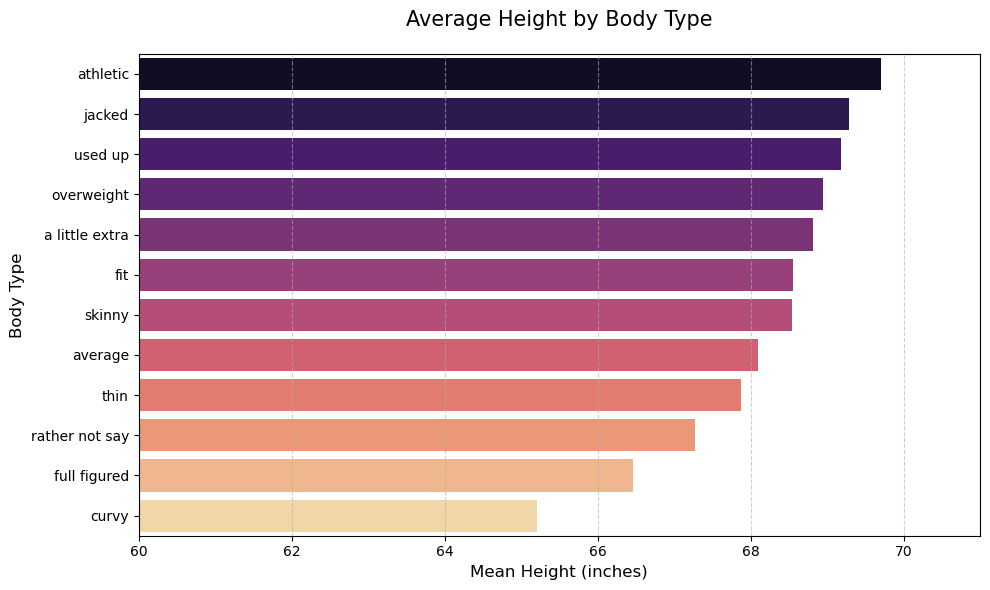

In [41]:
#visualizing the data for average hieght by body type
plot_data = height_body.reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='mean', y='body_type', palette='magma',hue='body_type', legend=False)

plt.title('Average Height by Body Type', fontsize=15, pad=20)
plt.xlabel('Mean Height (inches)', fontsize=12)
plt.ylabel('Body Type', fontsize=12)

# 4. Zoom in on the x-axis to show the differences better
# Since heights are between 65 and 70, we start the axis at 60
plt.xlim(60, 71)

# 5. Add a grid for easier reading
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6: Income Analysis

### 1. Income Distribution across the platform

count      11504.00
mean      104394.99
std       201433.53
min        20000.00
25%        20000.00
50%        50000.00
75%       100000.00
max      1000000.00
Name: income, dtype: float64


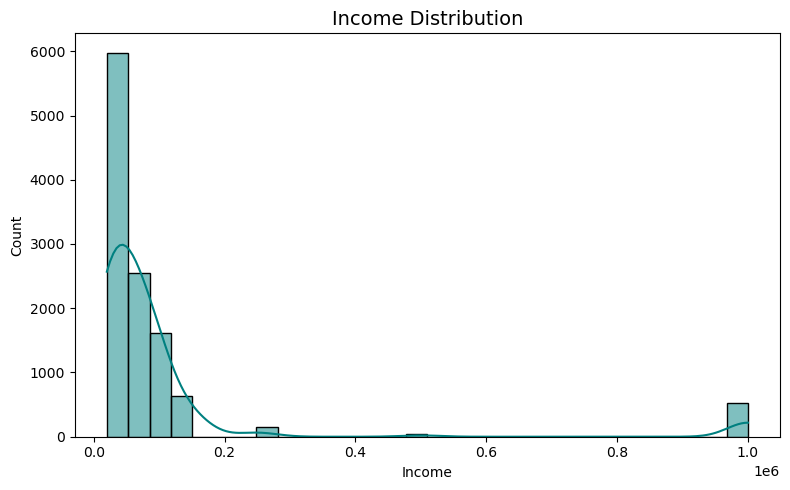

In [42]:
# Filter valid income (excluding NaN)
valid_income = df[df['income'].notna()]

print(valid_income['income'].describe().round(2))

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(valid_income['income'], 
             bins=30, 
             kde=True,
             color='teal')

plt.title('Income Distribution', fontsize=14)
plt.xlabel('Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Income variation by Age Group & Gender

In [43]:
# Income by age group and gender
income_age_gender = (df[df['income'].notna()]
                     .groupby(['age_group', 'gender'])['income']
                     .agg(['mean', 'median'])
                     .round(2))

(income_age_gender)

mean   median
age_group gender                    
18-25     f        86964.50  20000.0
          m       107654.80  30000.0
26-35     f        90398.13  40000.0
          m       114944.80  60000.0
36-45     f        87302.98  60000.0
          m       112680.61  80000.0
46+       f        75299.76  60000.0
          m       100156.63  80000.0

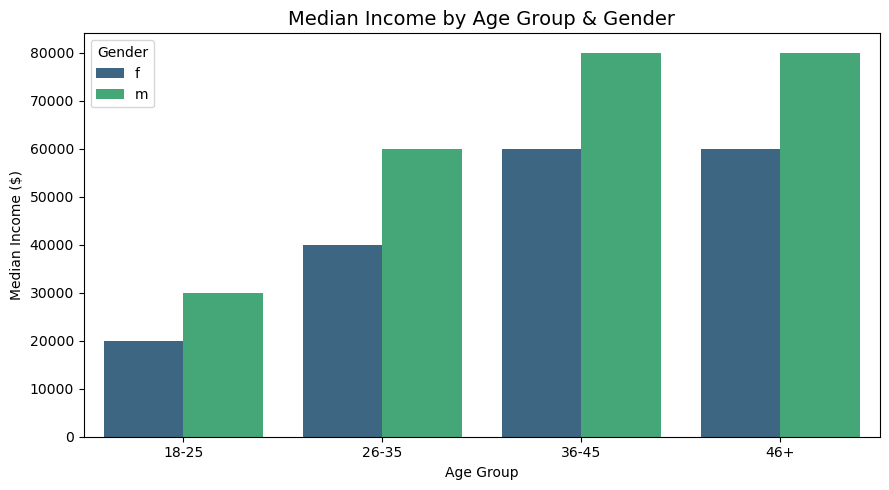

In [44]:
# Reset index for easier plotting
income_plot = (df[df['income'].notna()]
               .groupby(['age_group', 'gender'])['income']
               .median()
               .reset_index())
#choosing median because reliable given income skew 
plt.figure(figsize=(9, 5))
sns.barplot(data=income_plot,
            x='age_group',
            y='income',
            hue='gender',
            palette='viridis')

plt.title('Median Income by Age Group & Gender', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Median Income ($)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# part 4: Data Visualization

## 1. Age distribution

### Q1. histogram of age with a vertical line indicating the mean age.

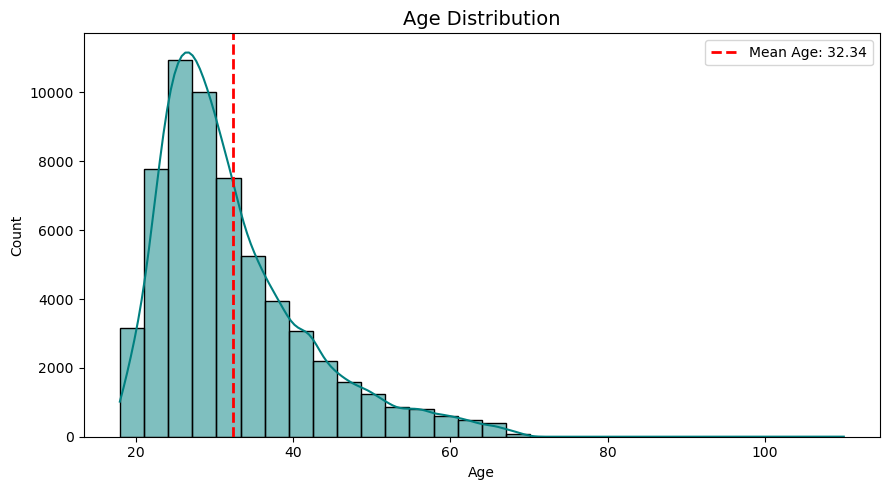

In [45]:
# Histogram of age with mean line
mean_age = df['age'].mean().round(2)

plt.figure(figsize=(9, 5))
sns.histplot(df['age'], bins=30, kde=True, color='teal')

plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean Age: {mean_age}')

plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Q2.  Age Distribution difference by Gender

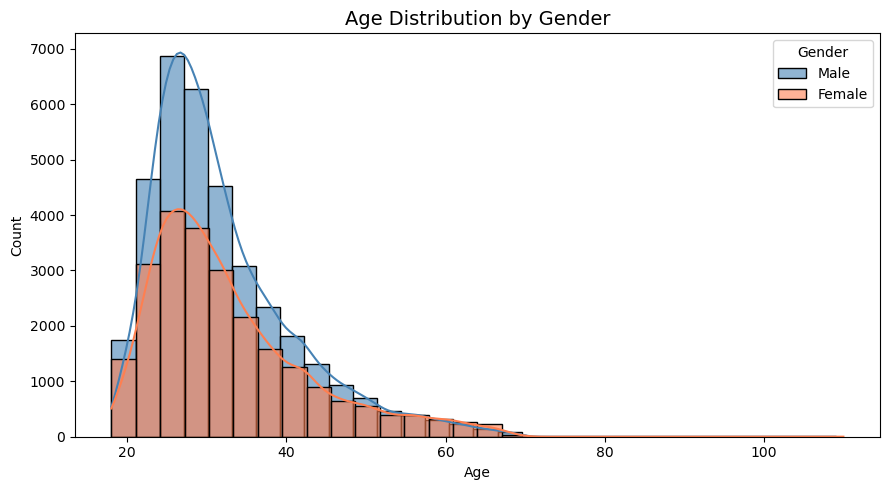

In [46]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df[df['gender'] == 'm'], 
             x='age', 
             bins=30, 
             kde=True,
             color='steelblue',
             alpha=0.6,
             label='Male')

sns.histplot(data=df[df['gender'] == 'f'], 
             x='age', 
             bins=30, 
             kde=True,
             color='coral',
             alpha=0.6,
             label='Female')

plt.title('Age Distribution by Gender', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 2. Income and Age


### Q1:  visualizing the relationship between income and age group sing a scatterplot 

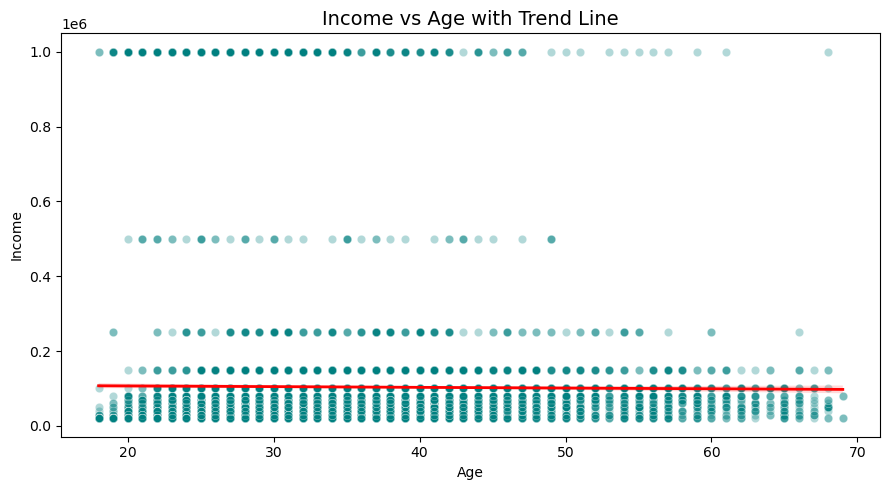

In [47]:
valid = df[df['income'].notna()]

plt.figure(figsize=(9, 5))
sns.scatterplot(data=valid,
                x='age',
                y='income',
                alpha=0.3,
                color='teal')

sns.regplot(data=valid,
            x='age',
            y='income',
            scatter=False,
            color='red',
            line_kws={'linewidth': 2})

plt.title('Income vs Age with Trend Line', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

### Q2: Boxplots visualization of Income by Age Group

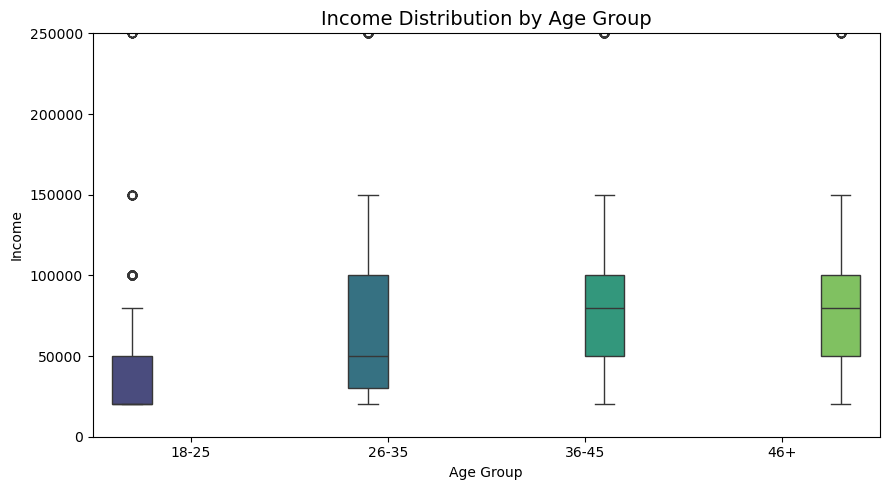

In [48]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[df['income'].notna()],
            x='age_group',
            y='income',
            hue='age_group',
            legend=False,
            palette='viridis')
plt.ylim(0, 250000) # ZOOM IN: Set the limit to $250,000 to see the boxes clearly
plt.title('Income Distribution by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

### Q3.Analyzing the Income levels by Gender & Status

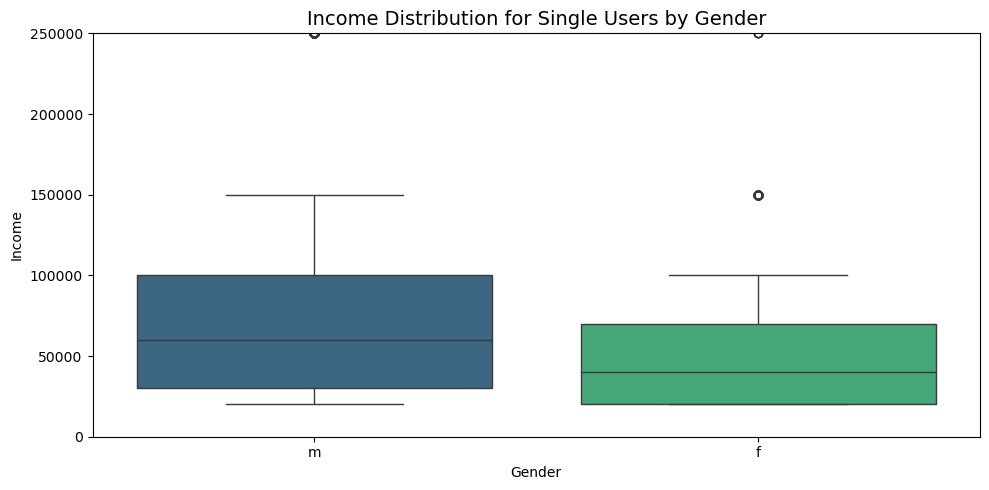

gender
f    40000.0
m    60000.0
Name: income, dtype: float64


In [49]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[(df['income'].notna()) & (df['status'] == 'single')],
            x='gender',
            y='income',
            hue='gender',
            legend=False,
            palette='viridis')
plt.ylim(0,250000)
plt.title('Income Distribution for Single Users by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

# Median values for comparison
print(df[(df['income'].notna()) & (df['status'] == 'single')]
      .groupby('gender')['income'].median())

## 3: Pets and Preferences

### Q1: visualizing the distribution of pets categories

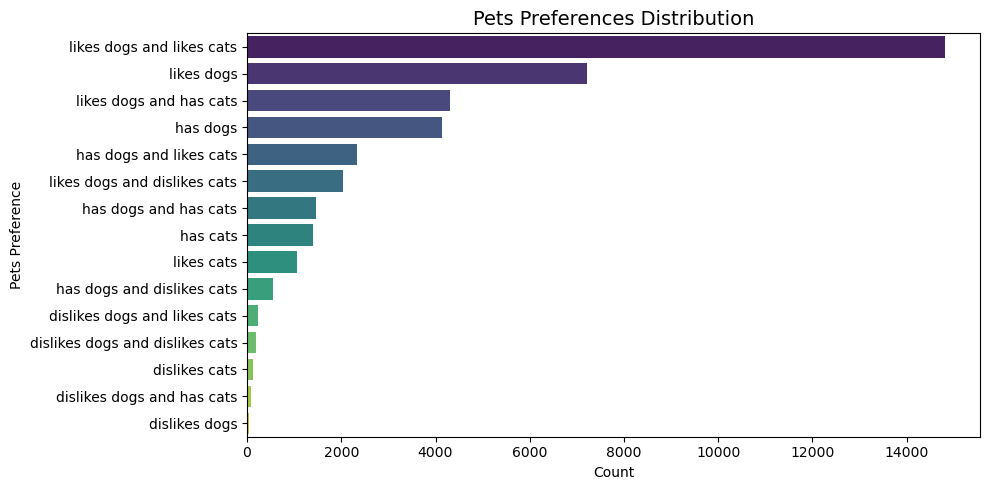

In [50]:
# Exclude unknown
pets_counts = df[df['pets'] != 'unknown']['pets'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=pets_counts.values,
            y=pets_counts.index,
            hue=pets_counts.index,
            legend=False,
            palette='viridis')

plt.title('Pets Preferences Distribution', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Pets Preference')
plt.tight_layout()
plt.show()

### Q2: Pets preferences by Gender & Age Group

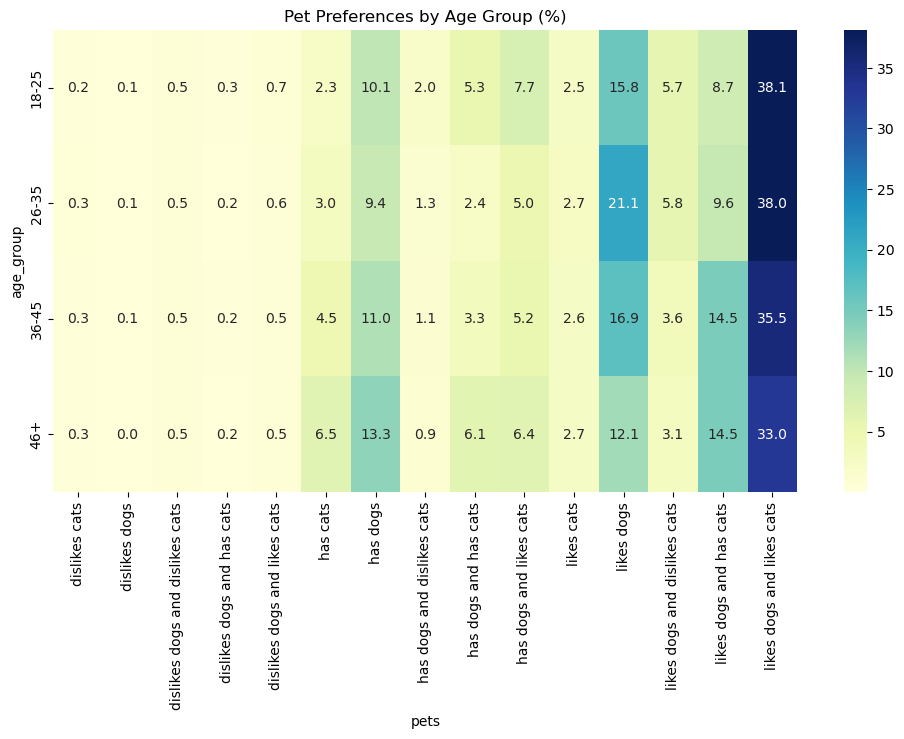

In [51]:
# Using the pets_age variable you already created in [64]
pets_age = (df[(df['pets'] != 'unknown')]
            .groupby(['age_group', 'pets'])
            .size()
            .unstack(fill_value=0)
            .apply(lambda x: (x/x.sum()*100).round(2), axis=1))

plt.figure(figsize=(12, 6))
sns.heatmap(pets_age, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Pet Preferences by Age Group (%)")
plt.show()

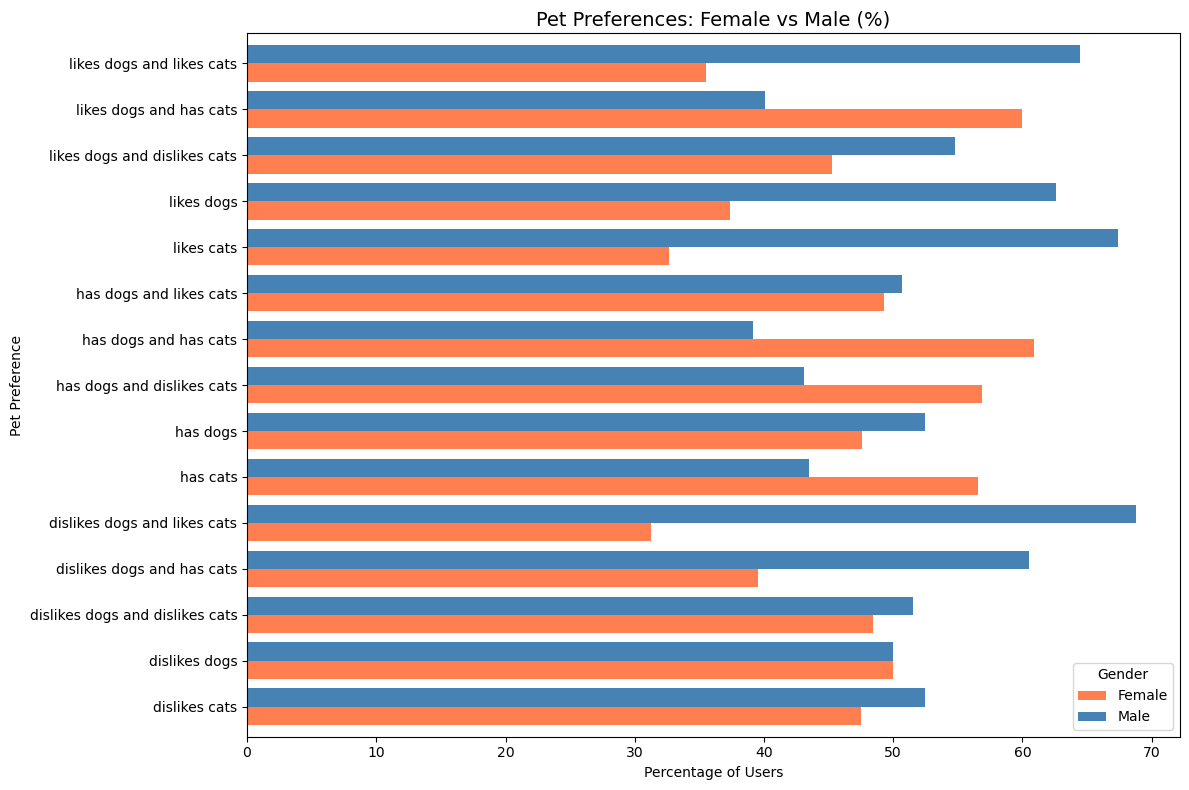

In [52]:
#pets ppreference by gender group
pets_gender = df[df['pets'] != 'unknown'].groupby(['pets', 'gender']).size().unstack()
pets_gender_pct = pets_gender.div(pets_gender.sum(axis=1), axis=0) * 100
pets_gender_pct.plot(kind='barh', figsize=(12, 8), color=['coral', 'steelblue'], width=0.8)

plt.title('Pet Preferences: Female vs Male (%)', fontsize=14)
plt.xlabel('Percentage of Users')
plt.ylabel('Pet Preference')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.show()

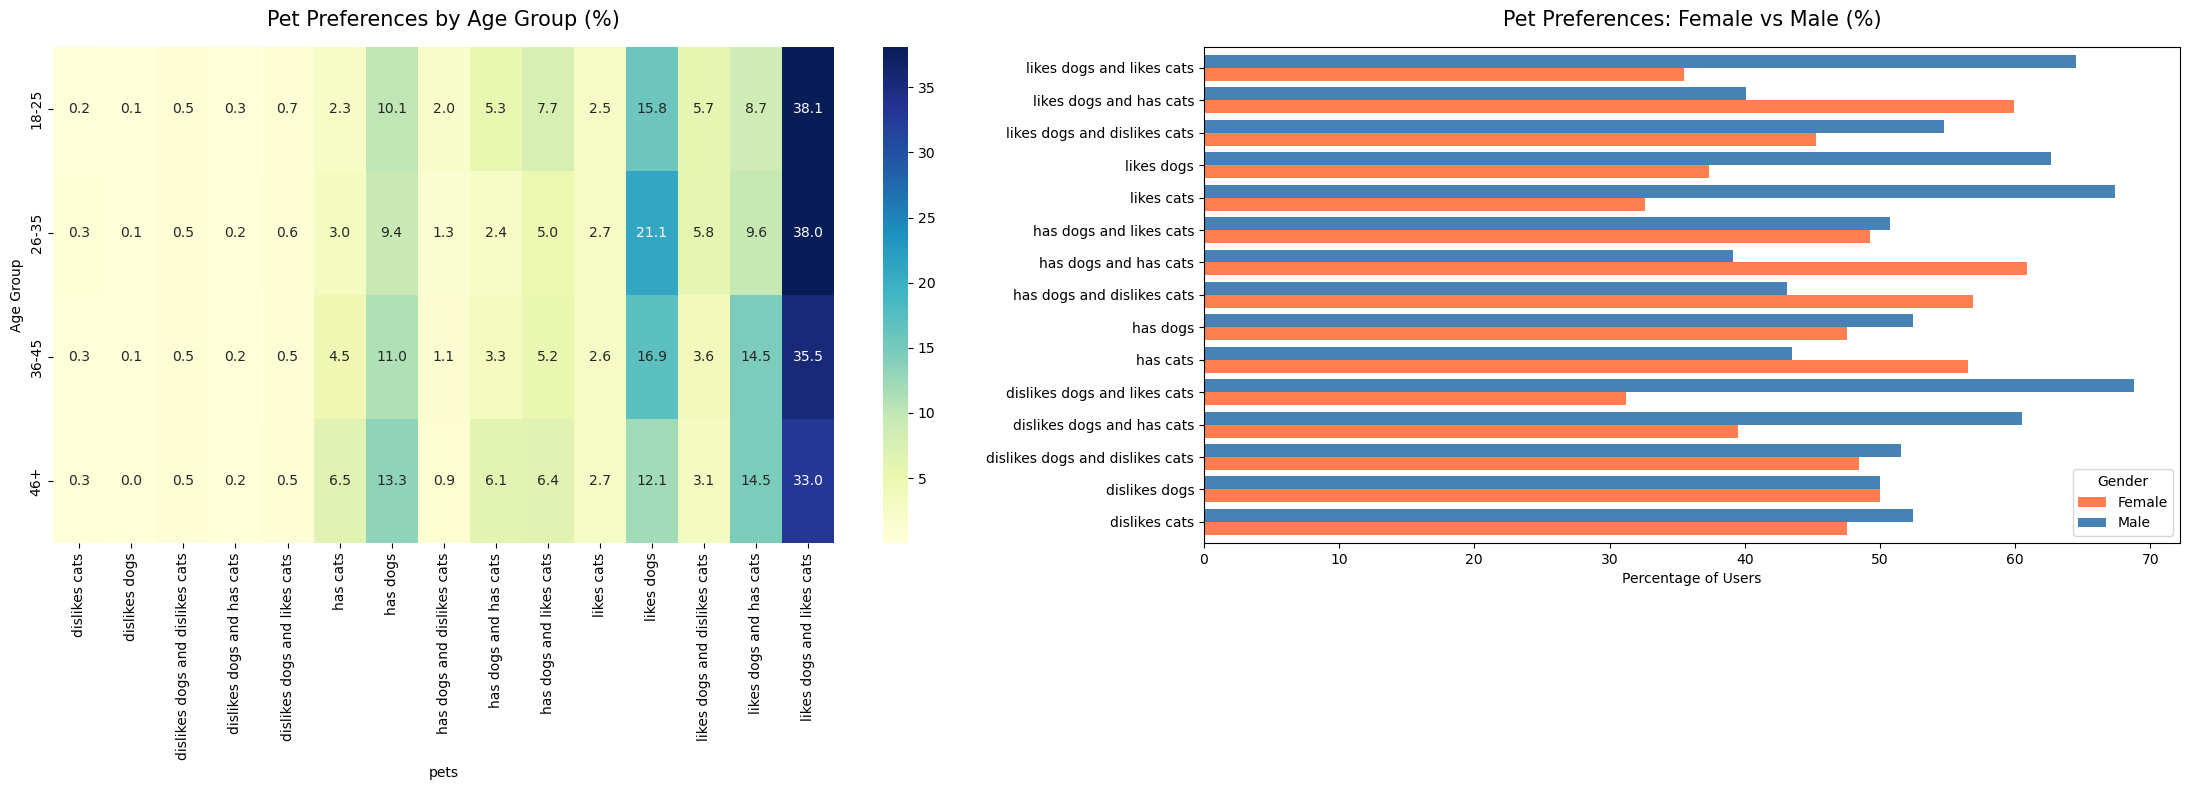

In [53]:
# 1. Prepare the Data
# Age Group Data
pets_age = (df[df['pets'] != 'unknown']
            .groupby(['age_group', 'pets']).size()
            .unstack(fill_value=0)
            .apply(lambda x: (x / x.sum() * 100).round(2), axis=1))

# Gender Data
pets_gender = df[df['pets'] != 'unknown'].groupby(['pets', 'gender']).size().unstack()
pets_gender_pct = pets_gender.div(pets_gender.sum(axis=1), axis=0) * 100

# 2. Create the Side-by-Side Plot
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Left Plot: Heatmap (Age Group)
sns.heatmap(pets_age, annot=True, cmap="YlGnBu", fmt=".1f", ax=axes[0])
axes[0].set_title("Pet Preferences by Age Group (%)", fontsize=15, pad=15)
axes[0].set_ylabel("Age Group")

# Right Plot: Horizontal Bar Chart (Gender)
pets_gender_pct.plot(kind='barh', color=['coral', 'steelblue'], width=0.8, ax=axes[1])
axes[1].set_title('Pet Preferences: Female vs Male (%)', fontsize=15, pad=15)
axes[1].set_xlabel('Percentage of Users')
axes[1].set_ylabel('') # Removed to avoid redundancy with the Y-axis labels
axes[1].legend(title='Gender', labels=['Female', 'Male'])

plt.tight_layout()
plt.show()

## 4: Signs and Personality

### Q1: Creating a pie chart showing the distribution of zodiac signs (sign) across the platform.

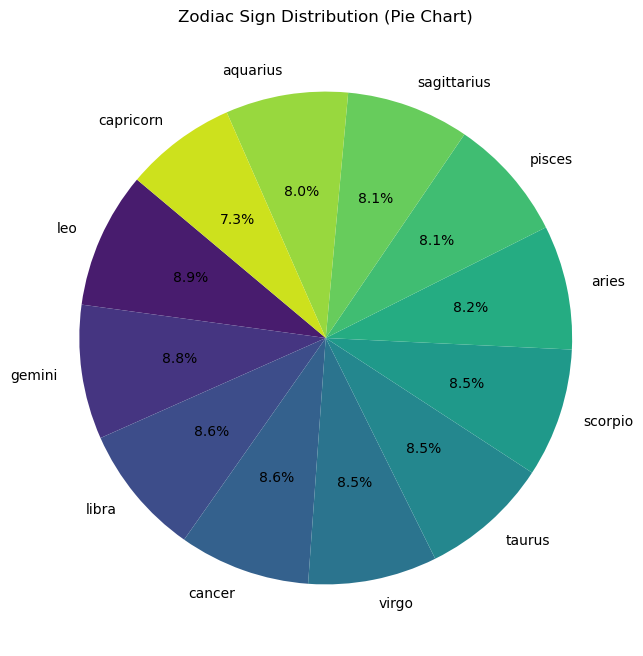

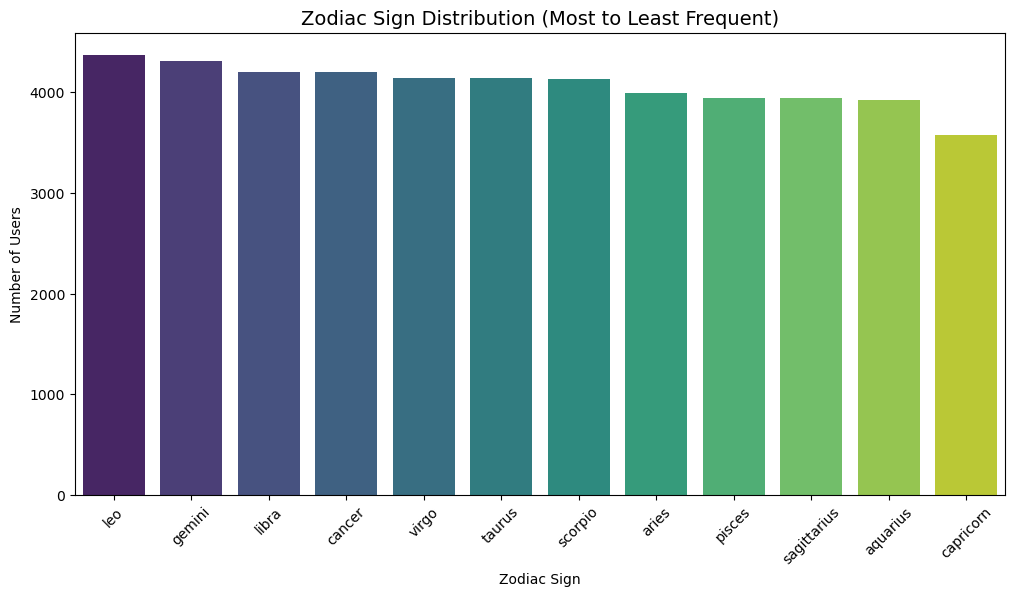

Most Represented: leo (4374 users)
Least Represented: capricorn (3573 users)


In [54]:
# 1. Clean the 'sign' column to get just the main Zodiac name
# This takes 'Aries but it doesn't matter' and turns it into just 'Aries'
df['clean_sign'] = df['sign'].str.split().str[0]

# 2. Filter out 'unknown'
sign_data = df[df['clean_sign'] != 'unknown']['clean_sign'].value_counts()

# --- OPTION A: THE PIE CHART 
plt.figure(figsize=(10, 8))
plt.pie(sign_data, labels=sign_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', 12))
plt.title('Zodiac Sign Distribution (Pie Chart)')
plt.show()

# --- OPTION B: THE "RIGHT" CHART (Sorted Bar Chart) ---
plt.figure(figsize=(12, 6))
sns.barplot(x=sign_data.index, y=sign_data.values, palette='viridis', hue=sign_data.index, legend=False)
plt.title('Zodiac Sign Distribution (Most to Least Frequent)', fontsize=14)
plt.xlabel('Zodiac Sign')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

# Identify Most and Least Represented
print(f"Most Represented: {sign_data.idxmax()} ({sign_data.max()} users)")
print(f"Least Represented: {sign_data.idxmin()} ({sign_data.min()} users)")

### Q2: Variation of signs by gender and status

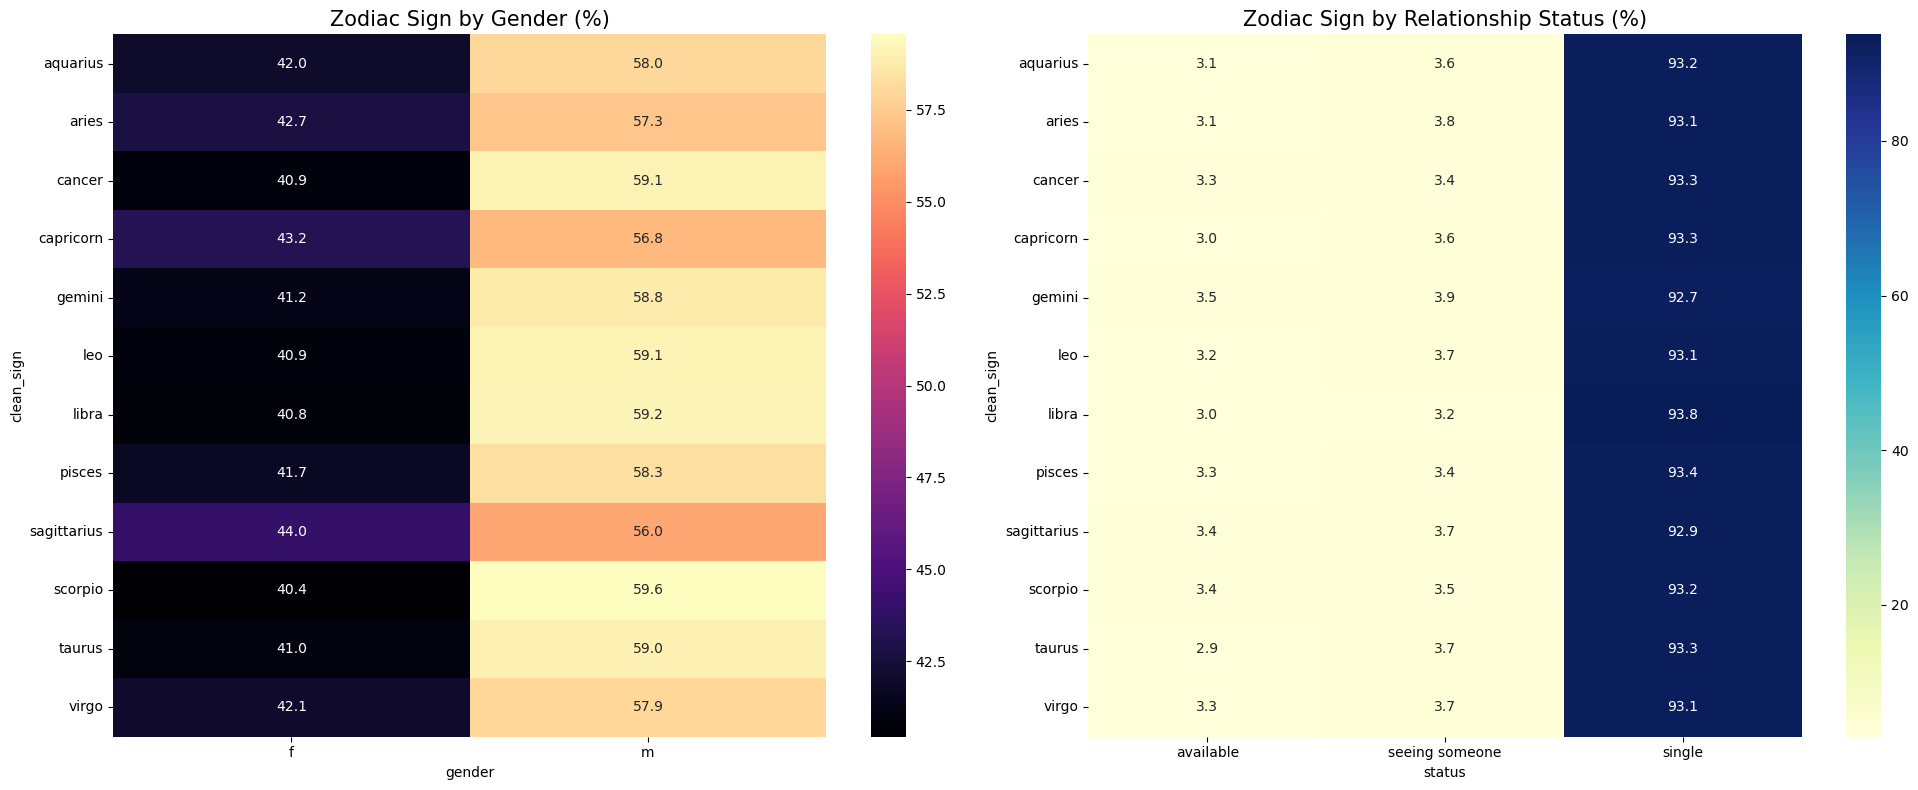

In [55]:
# 1. Prepare data for Sign vs Gender
sign_gender = pd.crosstab(df[df['clean_sign'] != 'unknown']['clean_sign'], df['gender'], normalize='index') * 100

# 2. Prepare data for Sign vs Status (Filtering for the main statuses)
main_statuses = ['single', 'seeing someone', 'available']
sign_status = pd.crosstab(df[(df['clean_sign'] != 'unknown') & (df['status'].isin(main_statuses))]['clean_sign'], 
                          df['status'], normalize='index') * 100

# 3. Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gender Heatmap
sns.heatmap(sign_gender, annot=True, cmap='magma', fmt=".1f", ax=axes[0])
axes[0].set_title('Zodiac Sign by Gender (%)', fontsize=15)

# Status Heatmap
sns.heatmap(sign_status, annot=True, cmap='YlGnBu', fmt=".1f", ax=axes[1])
axes[1].set_title('Zodiac Sign by Relationship Status (%)', fontsize=15)

plt.tight_layout()
plt.show()

### Final Key Takeaways
* **Demographics:** Bumble is dominated by 26-35 year old single males, primarily based in California (San Francisco).
* **Income Paradox:** While the mean is high ($104k), the median ($50k) is the real story. 80% of users chose not to report income, suggesting it's a sensitive field.
* **Gender Insights:** A notable gap exists in reported income; single men report a $20k higher median income than single women.
* **Lifestyle:** The community is overwhelmingly pet-friendly (dog & cat lovers) and "social drinkers" with flexible dietary habits.
* **Data Quality:** Average profile completeness is ~79%. Users are happy to share height and age but gatekeep religion and income.

---
## Author & Credits
**Project Created by:** Tarun Dagudu <br>
**Role:** Data Analyst  
**Tools Used:** Python (Pandas, NumPy), Seaborn, Matplotlib  
